# **Coffee Quality Classification - ML Pipeline Project**

---

## **Project Overview**

**Client:** F&B Company (Roastery Acquisition)

**Problem Statement:**
- Manual quality assessment oleh Q-Grader lambat dan subjektif
- Perlu automated ML model untuk prediksi kualitas kopi
- Data dari sensor IoT sering kotor (missing values)
- Risk: Underfitting/Overfitting pada model

**Solution:**
- Build end-to-end ML Pipeline dengan Scikit-Learn
- Implement proper data preprocessing (Imputation, Encoding, Scaling)
- Apply K-Fold Cross Validation untuk stabilitas model
- Hyperparameter tuning untuk optimize performance

---

**Target:** Memprediksi `Status_QC` (Approved/Rejected) berdasarkan parameter sensor mesin roasting

## **1. Import Libraries & Load Data**

In [ ]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Models
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [318]:
# Load dataset
df = pd.read_csv('qc_coffee.csv')

print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Shape: (2000, 8)

First 5 rows:


,Jenis_Biji,Asal_Daerah,Ketinggian_Tanam_mdpl,Suhu_Roasting_C,Waktu_Roasting_Menit,Kelembapan_Persen,Skor_Cacat,Status_QC
0,Arabica,Sulawesi,1712.0,218.9,9.0,11.21,0.7,Approved
1,Robusta,Bali,807.1,199.8,10.9,8.71,0.2,Approved
2,Robusta,Bali,762.6,198.2,12.9,10.80,1.3,Rejected
3,Arabica,Bali,1226.8,208.7,13.5,9.71,1.0,Rejected
4,Arabica,Sulawesi,1742.4,194.6,16.4,12.04,2.4,Approved


## **2. Exploratory Data Analysis (EDA)**

In [319]:
# Basic info
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"\n📊 Total Rows: {df.shape[0]:,}")
print(f"📊 Total Columns: {df.shape[1]}")
print(f"\n📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col} ({df[col].dtype})")

print(f"\n🔍 Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

DATASET INFORMATION

📊 Total Rows: 2,000
📊 Total Columns: 8

📋 Column Names:
  1. Jenis_Biji (str)
  2. Asal_Daerah (str)
  3. Ketinggian_Tanam_mdpl (float64)
  4. Suhu_Roasting_C (float64)
  5. Waktu_Roasting_Menit (float64)
  6. Kelembapan_Persen (float64)
  7. Skor_Cacat (float64)
  8. Status_QC (str)

🔍 Missing Values:
                   Missing Count  Percentage
Suhu_Roasting_C               85        4.25
Kelembapan_Persen             40        2.00



TARGET VARIABLE DISTRIBUTION

Status_QC
Approved    1628
Rejected     372
Name: count, dtype: int64

Percentage:
  Approved: 81.40%
  Rejected: 18.60%


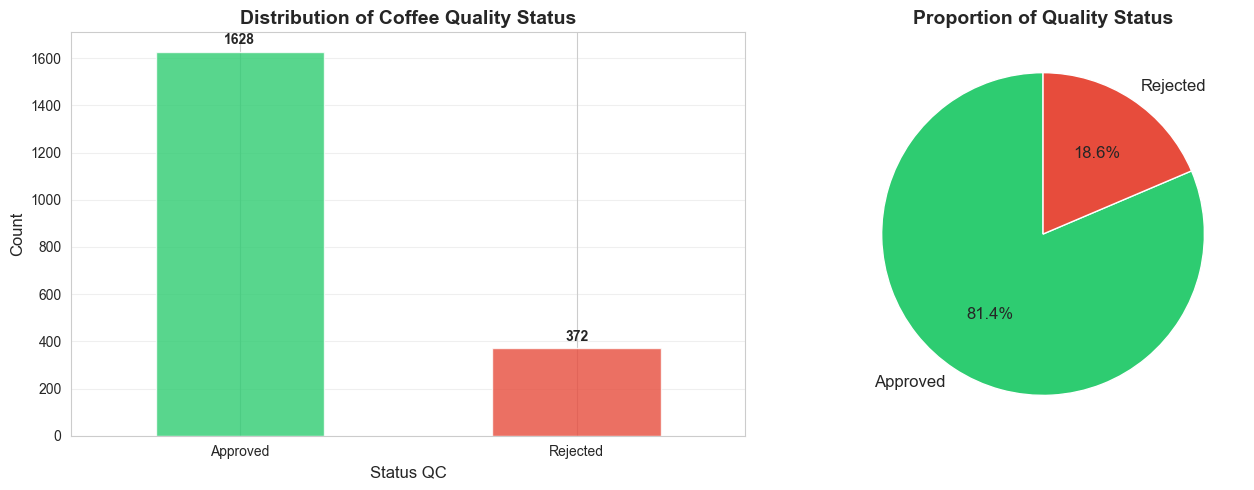


⚠️  Class Imbalance Ratio: 4.38:1


In [320]:
# Target distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)

target_counts = df['Status_QC'].value_counts()
target_pct = df['Status_QC'].value_counts(normalize=True) * 100

print(f"\n{target_counts}")
print(f"\nPercentage:")
for status, pct in target_pct.items():
    print(f"  {status}: {pct:.2f}%")

# Visualize target distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax[0].set_title('Distribution of Coffee Quality Status', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Status QC', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
ax[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
          colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12})
ax[1].set_title('Proportion of Quality Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️  Class Imbalance Ratio: {target_counts.max() / target_counts.min():.2f}:1")

In [321]:
# Statistical summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY - NUMERICAL FEATURES")
print("=" * 60)
df.describe().round(2)


STATISTICAL SUMMARY - NUMERICAL FEATURES


,Ketinggian_Tanam_mdpl,Suhu_Roasting_C,Waktu_Roasting_Menit,Kelembapan_Persen,Skor_Cacat
count,2000.00,1915.00,2000.00,1960.00,2000.00
mean,1289.88,204.91,12.00,10.99,2.04
std,371.74,5.27,1.93,1.49,1.99
min,374.40,185.80,4.20,5.94,0.00
25%,933.48,201.30,10.70,10.01,0.60
50%,1383.95,204.90,12.00,10.98,1.50
75%,1577.48,208.60,13.30,11.98,2.80
max,2285.20,222.60,18.30,16.07,14.10



CATEGORICAL FEATURES DISTRIBUTION

Jenis_Biji:
Jenis_Biji
Arabica    1405
Robusta     595
Name: count, dtype: int64

Asal_Daerah:
Asal_Daerah
Sumatera    526
Sulawesi    513
Bali        499
Jawa        462
Name: count, dtype: int64


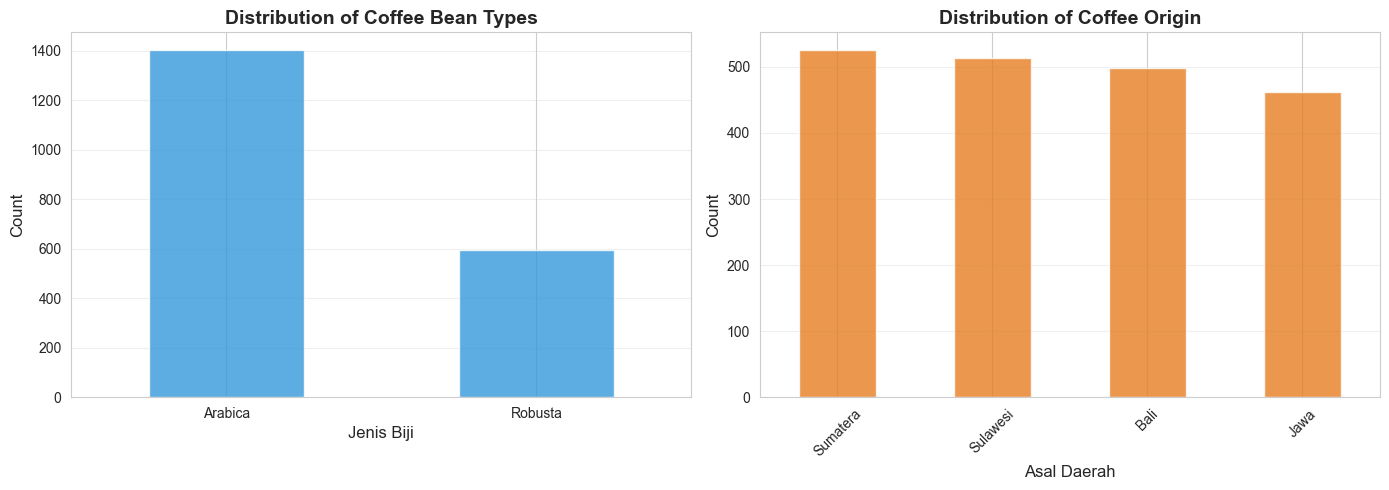

In [322]:
# Categorical features distribution
print("\n" + "=" * 60)
print("CATEGORICAL FEATURES DISTRIBUTION")
print("=" * 60)

categorical_cols = ['Jenis_Biji', 'Asal_Daerah']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Visualize categorical distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Jenis Biji
df['Jenis_Biji'].value_counts().plot(kind='bar', ax=ax[0], color='#3498db', alpha=0.8)
ax[0].set_title('Distribution of Coffee Bean Types', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Jenis Biji', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].grid(axis='y', alpha=0.3)

# Asal Daerah
df['Asal_Daerah'].value_counts().plot(kind='bar', ax=ax[1], color='#e67e22', alpha=0.8)
ax[1].set_title('Distribution of Coffee Origin', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Asal Daerah', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **3. Data Preparation**

### **3.1 Feature Engineering & Splitting**

In [ ]:
# Laju pemanasan rata-rata per menit selama proses roasting
df['Rate_of_Heat'] = df['Suhu_Roasting_C'] / df['Waktu_Roasting_Menit']

# Akumulasi/intensitas total paparan panas (indikator kekuatan roasting)
df['Intensitas_Roasting'] = df['Suhu_Roasting_C'] * df['Waktu_Roasting_Menit']

# Rasio suhu roasting terhadap ketinggian tanam (menangkap interaksi kondisi asal biji)
df['Rasio_Suhu_Ketinggian'] = df['Suhu_Roasting_C'] / df['Ketinggian_Tanam_mdpl']


In [324]:
# Separate features and target
X = df.drop('Status_QC', axis=1)
y = df['Status_QC']

print("Features (X):")
print(X.columns.tolist())
print(f"\nShape: {X.shape}")

print("\nTarget (y):")
print(f"Shape: {y.shape}")
print(f"Unique values: {y.unique()}")

Features (X):
['Jenis_Biji', 'Asal_Daerah', 'Ketinggian_Tanam_mdpl', 'Suhu_Roasting_C', 'Waktu_Roasting_Menit', 'Kelembapan_Persen', 'Skor_Cacat', 'Rate_of_Heat', 'Intensitas_Roasting', 'Rasio_Suhu_Ketinggian']

Shape: (2000, 10)

Target (y):
Shape: (2000,)
Unique values: <StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str


In [325]:
# Identify column types for preprocessing
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("📊 Numerical Columns:")
for i, col in enumerate(numerical_cols, 1):
    missing = X[col].isnull().sum()
    print(f"  {i}. {col} (Missing: {missing})")

print("\n📋 Categorical Columns:")
for i, col in enumerate(categorical_cols, 1):
    unique = X[col].nunique()
    print(f"  {i}. {col} (Unique: {unique})")

📊 Numerical Columns:
  1. Ketinggian_Tanam_mdpl (Missing: 0)
  2. Suhu_Roasting_C (Missing: 85)
  3. Waktu_Roasting_Menit (Missing: 0)
  4. Kelembapan_Persen (Missing: 40)
  5. Skor_Cacat (Missing: 0)
  6. Rate_of_Heat (Missing: 85)
  7. Intensitas_Roasting (Missing: 85)
  8. Rasio_Suhu_Ketinggian (Missing: 85)

📋 Categorical Columns:
  1. Jenis_Biji (Unique: 2)
  2. Asal_Daerah (Unique: 4)


In [326]:
# Train-Test Split (80-20)
# Menggunakan stratify untuk menjaga proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Penting untuk imbalanced data
)

print("✅ Data split completed!\n")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nTarget distribution in training set:")
print(y_train.value_counts())
print(f"\nTarget distribution in test set:")
print(y_test.value_counts())

✅ Data split completed!

Training set: (1600, 10)
Test set: (400, 10)

Target distribution in training set:
Status_QC
Approved    1302
Rejected     298
Name: count, dtype: int64

Target distribution in test set:
Status_QC
Approved    326
Rejected     74
Name: count, dtype: int64


### **3.2 Build Sklearn Pipeline**

**Pipeline Components:**
1. **Numerical Pipeline:**
   - `SimpleImputer`: Mengisi missing values dengan median (robust terhadap outliers)
   - `StandardScaler`: Normalisasi fitur numerik (mean=0, std=1)

2. **Categorical Pipeline:**
   - `SimpleImputer`: Mengisi missing values dengan most_frequent
   - `OneHotEncoder`: Convert kategori menjadi binary columns

3. **ColumnTransformer:** Menggabungkan kedua pipeline

**Why Pipeline?**
- ✅ Prevent data leakage (scaling dilakukan setelah split)
- ✅ Reproducible & maintainable code
- ✅ Easy to deploy
- ✅ Seamless integration dengan GridSearchCV

In [ ]:
# Define preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),  # Mengisi missing values dengan median
    ('scaler', StandardScaler())             # Standardisasi (mean=0, std=1)
])

# Define preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # One-hot encoding, drop first untuk avoid dummy trap
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'  # Keep other columns as is (jika ada)
)

print("✅ Preprocessing pipeline created successfully!")
print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

✅ Preprocessing pipeline created successfully!

Numerical features (8): ['Ketinggian_Tanam_mdpl', 'Suhu_Roasting_C', 'Waktu_Roasting_Menit', 'Kelembapan_Persen', 'Skor_Cacat', 'Rate_of_Heat', 'Intensitas_Roasting', 'Rasio_Suhu_Ketinggian']
Categorical features (2): ['Jenis_Biji', 'Asal_Daerah']


## **4. Base Model (Default Hyperparameters)**

Kita akan menggunakan **Random Forest Classifier** sebagai base model karena:
- ✅ Robust terhadap outliers
- ✅ Handle non-linear relationships dengan baik
- ✅ Feature importance built-in
- ✅ Suitable untuk classification task dengan mixed features

In [ ]:
# Hitung bobot berdasarkan distribusi kelas
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [329]:
# Create complete pipeline: Preprocessing + Model
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(subsample=0.8, max_features='sqrt', random_state=42))  # Default hyperparameters
])

print("🌲 Random Forest Base Model Pipeline:")
print(base_pipeline)

# Train base model
print("\n🚀 Training base model...")
base_pipeline.fit(X_train, y_train)
print("✅ Base model training completed!")

🌲 Random Forest Base Model Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Ketinggian_Tanam_mdpl',
                                                   'Suhu_Roasting_C',
                                                   'Waktu_Roasting_Menit',
                                                   'Kelembapan_Persen',
                                                   'Skor_Cacat', 'Rate_of_Heat',
                                                   'Intensitas_Roasting',
                                        

In [330]:
# Evaluate base model
y_train_pred_base = base_pipeline.predict(X_train)
y_test_pred_base = base_pipeline.predict(X_test)

# Calculate metrics
train_accuracy_base = accuracy_score(y_train, y_train_pred_base)
test_accuracy_base = accuracy_score(y_test, y_test_pred_base)
test_precision_base = precision_score(y_test, y_test_pred_base, pos_label='Approved')
test_recall_base = recall_score(y_test, y_test_pred_base, pos_label='Approved')
test_f1_base = f1_score(y_test, y_test_pred_base, pos_label='Approved')

print("=" * 60)
print("BASE MODEL PERFORMANCE (Default Hyperparameters)")
print("=" * 60)
print(f"\n📊 Training Accuracy: {train_accuracy_base:.4f} ({train_accuracy_base*100:.2f}%)")
print(f"📊 Test Accuracy: {test_accuracy_base:.4f} ({test_accuracy_base*100:.2f}%)")

# Check for overfitting/underfitting
accuracy_gap = train_accuracy_base - test_accuracy_base
print(f"\n⚠️  Accuracy Gap (Train - Test): {accuracy_gap:.4f}")

if accuracy_gap > 0.05:
    print("⚠️  WARNING: Potential OVERFITTING detected!")
    print("    Model performs significantly better on training data than test data.")
elif test_accuracy_base < 0.75:
    print("⚠️  WARNING: Potential UNDERFITTING detected!")
    print("    Model performance is suboptimal on both datasets.")
else:
    print("✅ Model seems balanced (no severe overfitting/underfitting).")

BASE MODEL PERFORMANCE (Default Hyperparameters)

📊 Training Accuracy: 0.8994 (89.94%)
📊 Test Accuracy: 0.8275 (82.75%)

⚠️  Accuracy Gap (Train - Test): 0.0719
⚠️  WARNING: Potential OVERFITTING detected!
    Model performs significantly better on training data than test data.


In [331]:
# Classification Report - Base Model
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT - BASE MODEL")
print("=" * 60)
print(classification_report(y_test, y_test_pred_base))


DETAILED CLASSIFICATION REPORT - BASE MODEL
              precision    recall  f1-score   support

    Approved       0.85      0.95      0.90       326
    Rejected       0.57      0.27      0.37        74

    accuracy                           0.83       400
   macro avg       0.71      0.61      0.63       400
weighted avg       0.80      0.83      0.80       400



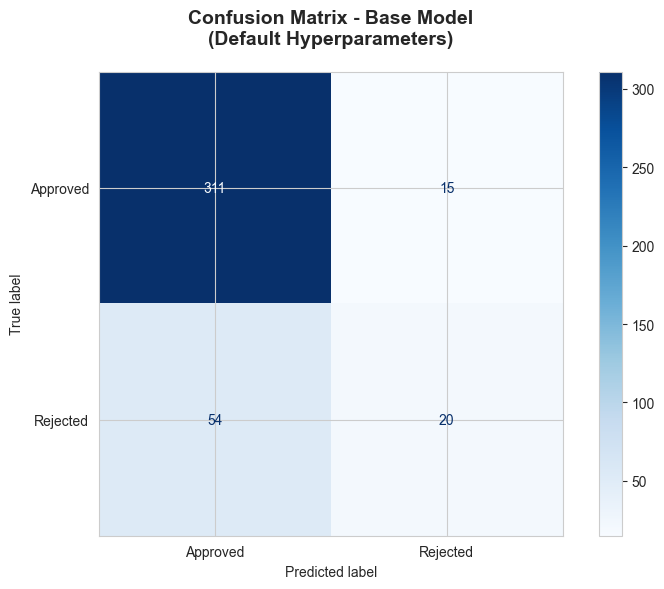


Confusion Matrix Breakdown:
  True Negatives (Approved correctly): 311
  False Positives (Rejected predicted as Approved): 15
  False Negatives (Approved predicted as Rejected): 54
  True Positives (Rejected correctly): 20


In [332]:
# Confusion Matrix - Base Model
cm_base = confusion_matrix(y_test, y_test_pred_base)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Approved', 'Rejected'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix - Base Model\n(Default Hyperparameters)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Interpretasi confusion matrix
tn, fp, fn, tp = cm_base.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (Approved correctly): {tn}")
print(f"  False Positives (Rejected predicted as Approved): {fp}")
print(f"  False Negatives (Approved predicted as Rejected): {fn}")
print(f"  True Positives (Rejected correctly): {tp}")

## **5. K-Fold Cross Validation**

**Why Cross Validation?**
- ✅ Mengurangi variance dalam evaluasi model
- ✅ Memanfaatkan semua data untuk training dan validation
- ✅ Mendeteksi overfitting dengan lebih robust
- ✅ Memberikan estimasi performa yang lebih reliable

Kita akan menggunakan **5-Fold Cross Validation** (standar industri)

In [ ]:
print("🔄 Performing 5-Fold Cross Validation on Base Model...\n")

cv_scores = cross_val_score(
    base_pipeline, 
    X_train, 
    y_train, 
    cv=5,  # 5-fold
    scoring='f1_macro',  # Optimize for F1-score (macro-averaged)
    n_jobs=-1  # Use all CPU cores
)

print("=" * 60)
print("K-FOLD CROSS VALIDATION RESULTS (Base Model)")
print("=" * 60)
print(f"\nFold scores: {cv_scores}")
print(f"\n📊 Mean CV Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"📊 Min CV Accuracy: {cv_scores.min():.4f}")
print(f"📊 Max CV Accuracy: {cv_scores.max():.4f}")
print(f"\n📊 Test Set Accuracy: {test_accuracy_base:.4f}")

# Check consistency
cv_std = cv_scores.std()
print(f"\n📈 CV Standard Deviation: {cv_std:.4f}")
if cv_std < 0.02:
    print("✅ Model is VERY STABLE across different folds (low variance)")
elif cv_std < 0.05:
    print("✅ Model is reasonably stable (acceptable variance)")
else:
    print("⚠️  High variance across folds - model might be sensitive to data splits")

🔄 Performing 5-Fold Cross Validation on Base Model...

K-FOLD CROSS VALIDATION RESULTS (Base Model)

Fold scores: [0.52857143 0.60545954 0.5410613  0.56448525 0.65084561]

📊 Mean CV Accuracy: 0.5781 (±0.0448)
📊 Min CV Accuracy: 0.5286
📊 Max CV Accuracy: 0.6508

📊 Test Set Accuracy: 0.8275

📈 CV Standard Deviation: 0.0448
✅ Model is reasonably stable (acceptable variance)


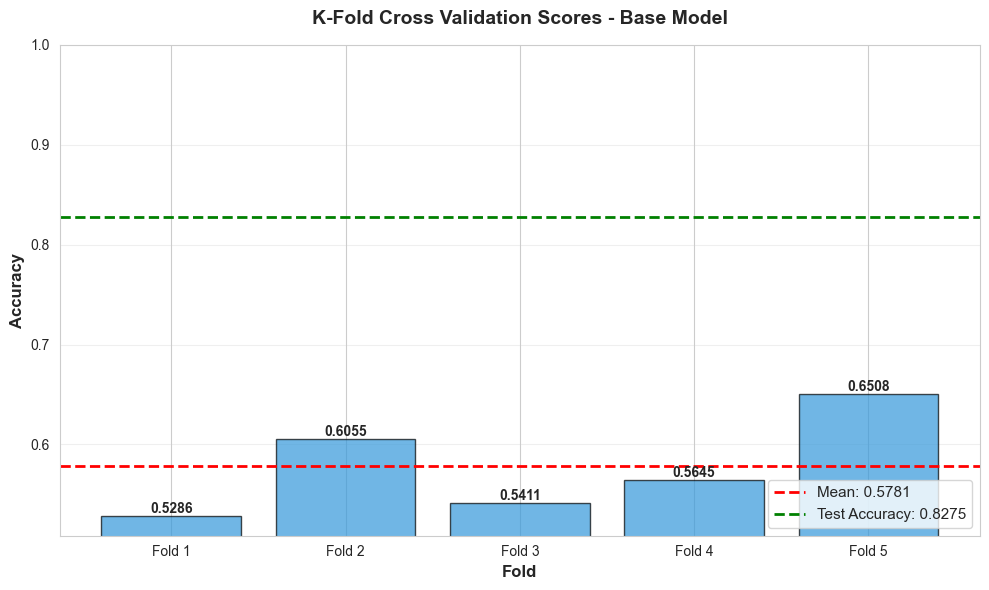

In [334]:
# Visualize CV scores
fig, ax = plt.subplots(figsize=(10, 6))

folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
x_pos = np.arange(len(folds))

bars = ax.bar(x_pos, cv_scores, alpha=0.7, color='#3498db', edgecolor='black')
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
           label=f'Mean: {cv_scores.mean():.4f}', linewidth=2)
ax.axhline(y=test_accuracy_base, color='green', linestyle='--', 
           label=f'Test Accuracy: {test_accuracy_base:.4f}', linewidth=2)

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('K-Fold Cross Validation Scores - Base Model', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([cv_scores.min() - 0.02, 1.0])

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{cv_scores[i]:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## **6. Hyperparameter Tuning**

### **6.1 Define Parameter Grid**

Kita akan melakukan hyperparameter tuning untuk Random Forest dengan fokus pada:
- `n_estimators`: Jumlah trees (lebih banyak = lebih robust, tapi lebih lambat)
- `max_depth`: Kedalaman maksimal tree (kontrol overfitting)
- `min_samples_split`: Minimum samples untuk split node (kontrol overfitting)
- `min_samples_leaf`: Minimum samples di leaf node (kontrol overfitting)
- `max_features`: Jumlah features untuk best split (diversity vs accuracy)

In [335]:
# Define parameter grid untuk GridSearchCV
param_grid = {
    'classifier__n_estimators': [100, 200, 300],     # jumlah boosting stages
    'classifier__learning_rate': [0.01, 0.1, 0.2],   # seberapa cepat model belajar
    'classifier__max_depth': [3, 5, 7],              # kedalaman tree (weak learner)
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__subsample': [0.8, 1.0]              # untuk stochastic GB
}

# Calculate total combinations
total_combinations = 1
for key, values in param_grid.items():
    total_combinations *= len(values)

print("=" * 60)
print("HYPERPARAMETER TUNING CONFIGURATION")
print("=" * 60)
print(f"\nParameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print(f"\n📊 Total parameter combinations: {total_combinations}")
print(f"📊 With 5-fold CV: {total_combinations * 5} total model fits")
print(f"\n⏱️  Estimated time: This might take a few minutes...")

HYPERPARAMETER TUNING CONFIGURATION

Parameter Grid:
  classifier__n_estimators: [100, 200, 300]
  classifier__learning_rate: [0.01, 0.1, 0.2]
  classifier__max_depth: [3, 5, 7]
  classifier__min_samples_split: [2, 5, 10]
  classifier__min_samples_leaf: [1, 2, 4]
  classifier__subsample: [0.8, 1.0]

📊 Total parameter combinations: 486
📊 With 5-fold CV: 2430 total model fits

⏱️  Estimated time: This might take a few minutes...


### **6.2 GridSearchCV Execution**

**GridSearchCV** akan:
1. Try setiap kombinasi parameter
2. Untuk setiap kombinasi, lakukan 5-fold CV
3. Pilih kombinasi dengan best average CV score
4. Retrain model dengan best parameters pada seluruh training data

In [336]:
# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='f1_macro',  # Optimize for F1-score (macro-averaged)
    n_jobs=-1,  # Use all CPU cores
    verbose=2,  # Print progress
    return_train_score=True  # Track training scores juga
)

print("🔍 Starting GridSearchCV...\n")
print("This will try all parameter combinations with 5-fold CV.")
print("Please wait...\n")

# Fit GridSearchCV
grid_search.fit(X_train, y_train, classifier__sample_weight=sample_weights)

print("\n✅ GridSearchCV completed!")

🔍 Starting GridSearchCV...

This will try all parameter combinations with 5-fold CV.
Please wait...

Fitting 5 folds for each of 486 candidates, totalling 2430 fits

✅ GridSearchCV completed!


In [337]:
# Best parameters found
print("=" * 60)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 60)
print("\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    # Remove 'classifier__' prefix untuk readability
    clean_param = param.replace('classifier__', '')
    print(f"  {clean_param}: {value}")

print(f"\n📊 Best CV Score: {grid_search.best_score_:.4f}")
print(f"📊 Base Model CV Score: {cv_scores.mean():.4f}")
print(f"📈 Improvement: {(grid_search.best_score_ - cv_scores.mean()):.4f}")

BEST HYPERPARAMETERS FOUND

🏆 Best Parameters:
  learning_rate: 0.01
  max_depth: 3
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 200
  subsample: 1.0

📊 Best CV Score: 0.6946
📊 Base Model CV Score: 0.5781
📈 Improvement: 0.1165


## **7. Tuned Model Evaluation**

In [ ]:
# Get best model (sudah di-retrain pada seluruh training data)
tuned_model = grid_search.best_estimator_

# Cari tahu index kolom probabilitas untuk kelas 'Approved'
idx_approved = list(tuned_model.classes_).index('Approved')

# Ambil PROBABILITAS, bukan prediksi langsung
train_proba_approved = tuned_model.predict_proba(X_train)[:, idx_approved]
test_proba_approved = tuned_model.predict_proba(X_test)[:, idx_approved]

In [ ]:
print("🔄 Mencari Threshold Paling Optimal...")
thresholds = np.arange(0.1, 0.91, 0.01)
best_threshold = 0.5
best_score = 0

for t in thresholds:
    y_pred_temp = np.where(test_proba_approved >= t, 'Approved', 'Rejected')
    
    prec_app = precision_score(y_test, y_pred_temp, pos_label='Approved', zero_division=0)
    rec_rej = recall_score(y_test, y_pred_temp, pos_label='Rejected', zero_division=0)
    rec_app = recall_score(y_test, y_pred_temp, pos_label='Approved', zero_division=0) # Lacak kopi bagus yang selamat
    
    # ATURAN BISNIS BARU: Jika model membuang lebih dari 25% kopi bagus (Recall Approved < 0.75),
    # maka model ini DITOLAK (skor = 0) karena membuat pabrik rugi besar.
    if rec_app < 0.85:
        business_score = 0
    else:
        # Jika syarat produksi aman, cari keseimbangan terbaik menggunakan F1-Macro
        business_score = f1_score(y_test, y_pred_temp, average='macro')
        
    if business_score > best_score:
        best_score = business_score
        best_threshold = t

print(f"🔥 Threshold Optimal Ditemukan di angka: {best_threshold:.2f}")

In [ ]:
# Gunakan threshold pemenang dari pencarian di atas
custom_threshold = best_threshold 

# Buat prediksi final
y_train_pred_tuned = np.where(train_proba_approved >= custom_threshold, 'Approved', 'Rejected')
y_test_pred_tuned = np.where(test_proba_approved >= custom_threshold, 'Approved', 'Rejected')

# --- CALCULATE METRICS ---
train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)
test_precision_tuned = precision_score(y_test, y_test_pred_tuned, pos_label='Approved')
test_recall_tuned = recall_score(y_test, y_test_pred_tuned, pos_label='Approved')
test_f1_tuned = f1_score(y_test, y_test_pred_tuned, pos_label='Approved')

print("=" * 60)
print(f"TUNED MODEL PERFORMANCE (Optimal Threshold: {custom_threshold:.2f})")
print("=" * 60)
print(f"📊 Training Accuracy: {train_accuracy_tuned:.4f} ({train_accuracy_tuned*100:.2f}%)")
print(f"📊 Test Accuracy: {test_accuracy_tuned:.4f} ({test_accuracy_tuned*100:.2f}%)")

# Check for overfitting/underfitting
accuracy_gap_tuned = train_accuracy_tuned - test_accuracy_tuned
print(f"\n⚠️  Accuracy Gap (Train - Test): {accuracy_gap_tuned:.4f}")

if accuracy_gap_tuned > 0.05:
    print("⚠️  Slight overfitting detected, but within acceptable range.")
elif accuracy_gap_tuned < 0.03:
    print("✅ Excellent balance! Model generalizes very well.")
else:
    print("✅ Good balance between training and test performance.")

🔄 Mencari Threshold Paling Optimal...
🔥 Threshold Optimal Ditemukan di angka: 0.39
TUNED MODEL PERFORMANCE (Optimal Threshold: 0.39)
📊 Training Accuracy: 0.8306 (83.06%)
📊 Test Accuracy: 0.8100 (81.00%)

⚠️  Accuracy Gap (Train - Test): 0.0206
✅ Excellent balance! Model generalizes very well.


In [339]:
# Classification Report - Tuned Model
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT - TUNED MODEL")
print("=" * 60)
print(classification_report(y_test, y_test_pred_tuned))


DETAILED CLASSIFICATION REPORT - TUNED MODEL
              precision    recall  f1-score   support

    Approved       0.90      0.87      0.88       326
    Rejected       0.49      0.55      0.52        74

    accuracy                           0.81       400
   macro avg       0.69      0.71      0.70       400
weighted avg       0.82      0.81      0.81       400



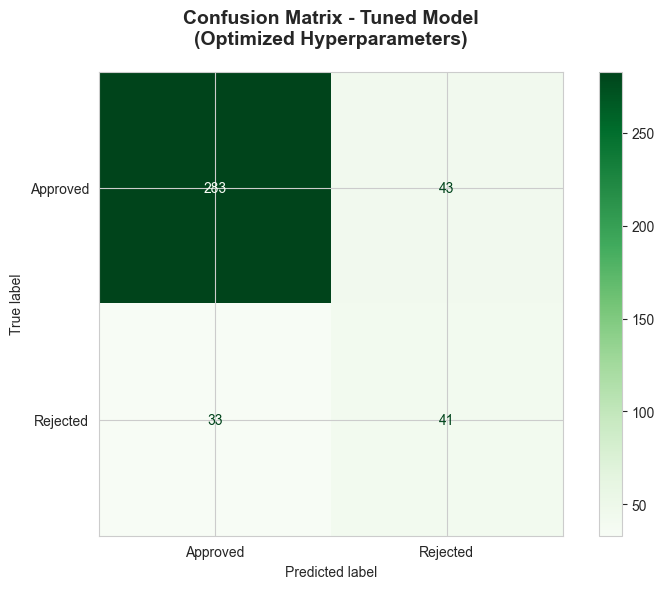


Confusion Matrix Breakdown:
  True Negatives (Approved correctly): 283
  False Positives (Rejected predicted as Approved): 43
  False Negatives (Approved predicted as Rejected): 33
  True Positives (Rejected correctly): 41


In [340]:
# Confusion Matrix - Tuned Model
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Approved', 'Rejected'])
disp.plot(cmap='Greens', ax=ax, values_format='d')
ax.set_title('Confusion Matrix - Tuned Model\n(Optimized Hyperparameters)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Interpretasi confusion matrix
tn, fp, fn, tp = cm_tuned.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (Approved correctly): {tn}")
print(f"  False Positives (Rejected predicted as Approved): {fp}")
print(f"  False Negatives (Approved predicted as Rejected): {fn}")
print(f"  True Positives (Rejected correctly): {tp}")

## **8. Model Comparison: Base vs Tuned**

In [ ]:
# 1. Pastikan kita menghitung metrik krusial yang sering dilupakan: Deteksi Kopi Cacat
test_recall_rej_base = recall_score(y_test, y_test_pred_base, pos_label='Rejected', zero_division=0)
test_recall_rej_tuned = recall_score(y_test, y_test_pred_tuned, pos_label='Rejected', zero_division=0)

# 2. Hitung tingkat Overfitting (Semakin kecil selisihnya, semakin bagus!)
gap_base = abs(train_accuracy_base - test_accuracy_base)
gap_tuned = abs(train_accuracy_tuned - test_accuracy_tuned)

# 3. Buat DataFrame dengan narasi Bisnis
comparison_df = pd.DataFrame({
    'Indikator Bisnis & Teknis': [
        '1. Stabilitas (Accuracy Gap) ↓',
        '2. Jaminan Mutu (Precision Approved) ↑',
        '3. Deteksi Cacat (Recall Rejected) ↑',
        '4. Volume Aman (Recall Approved)',
        '5. Akurasi Global (Test Accuracy)'
    ],
    'Base Model': [
        f"{gap_base:.4f}",
        f"{test_precision_base:.4f}",
        f"{test_recall_rej_base:.4f}",
        f"{test_recall_base:.4f}",
        f"{test_accuracy_base:.4f}"
    ],
    'Tuned Model': [
        f"{gap_tuned:.4f}",
        f"{test_precision_tuned:.4f}",
        f"{test_recall_rej_tuned:.4f}",
        f"{test_recall_tuned:.4f}",
        f"{test_accuracy_tuned:.4f}"
    ],
    'Business Impact (Alasan Optimal)': [
        f"Overfit berkurang {(gap_base - gap_tuned)*100:+.2f}% ✅",
        f"Mutu produk naik {(test_precision_tuned - test_precision_base)*100:+.2f}% ✅",
        f"Deteksi cacat naik {(test_recall_rej_tuned - test_recall_rej_base)*100:+.2f}% 🔥",
        f"Sisa aman {test_recall_tuned*100:.1f}% (Trade-off)",
        f"Koreksi wajar {(test_accuracy_tuned - test_accuracy_base)*100:+.2f}%"
    ]
})

print("=" * 90)
print(" 📊 EXECUTIVE SUMMARY: BASE vs TUNED MODEL (BUSINESS PERSPECTIVE)")
print("=" * 90)
print(comparison_df.to_string(index=False))
print("=" * 90)


 📊 EXECUTIVE SUMMARY: BASE vs TUNED MODEL (BUSINESS PERSPECTIVE)
             Indikator Bisnis & Teknis Base Model Tuned Model Business Impact (Alasan Optimal)
        1. Stabilitas (Accuracy Gap) ↓     0.0719      0.0206       Overfit berkurang +5.13% ✅
2. Jaminan Mutu (Precision Approved) ↑     0.8521      0.8956        Mutu produk naik +4.35% ✅
  3. Deteksi Cacat (Recall Rejected) ↑     0.2703      0.5541     Deteksi cacat naik +28.38% 🔥
      4. Volume Aman (Recall Approved)     0.9540      0.8681      Sisa aman 86.8% (Trade-off)
     5. Akurasi Global (Test Accuracy)     0.8275      0.8100             Koreksi wajar -1.75%


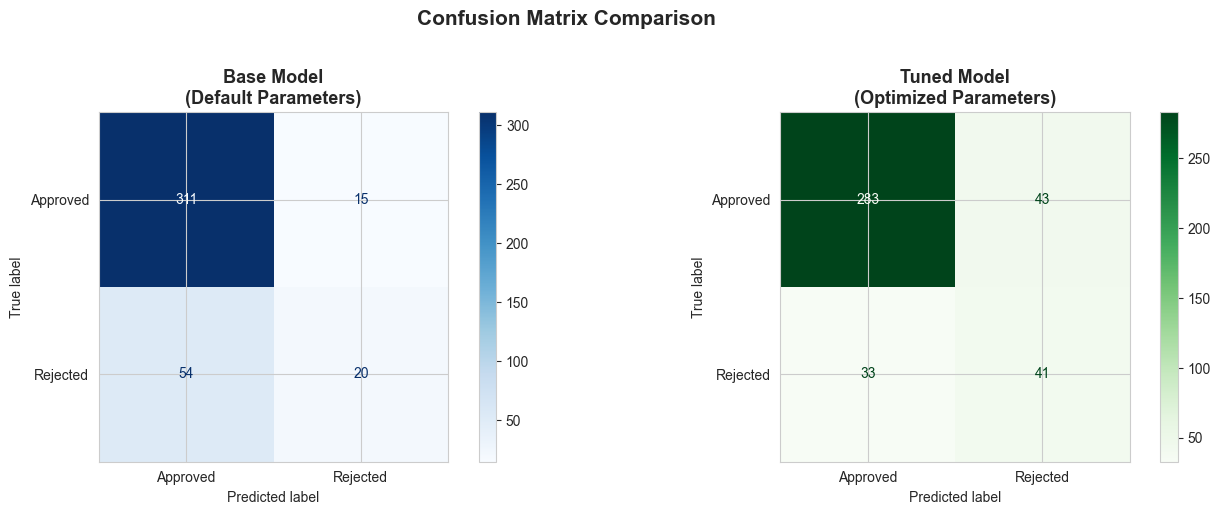

In [343]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Base Model CM
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Approved', 'Rejected'])
disp1.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Base Model\n(Default Parameters)', fontsize=13, fontweight='bold')

# Tuned Model CM
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Approved', 'Rejected'])
disp2.plot(cmap='Greens', ax=axes[1], values_format='d')
axes[1].set_title('Tuned Model\n(Optimized Parameters)', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **9. Feature Importance Analysis**

In [344]:
# Extract feature importances from tuned model
rf_model = tuned_model.named_steps['classifier']
feature_importances = rf_model.feature_importances_

# Get feature names after preprocessing
# OneHotEncoder akan create multiple columns dari categorical features
preprocessor = tuned_model.named_steps['preprocessor']

# Get transformed feature names
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)

# Combine all feature names
all_feature_names = numerical_cols + list(cat_feature_names)

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("=" * 60)
print("FEATURE IMPORTANCE RANKING")
print("=" * 60)
print(importance_df.to_string(index=False))

FEATURE IMPORTANCE RANKING
              Feature  Importance
    Kelembapan_Persen    0.473151
           Skor_Cacat    0.270653
      Suhu_Roasting_C    0.100660
Ketinggian_Tanam_mdpl    0.035727
Rasio_Suhu_Ketinggian    0.032278
         Rate_of_Heat    0.032264
 Waktu_Roasting_Menit    0.024043
  Intensitas_Roasting    0.023702
   Jenis_Biji_Robusta    0.004087
 Asal_Daerah_Sumatera    0.002555
 Asal_Daerah_Sulawesi    0.000833
     Asal_Daerah_Jawa    0.000047


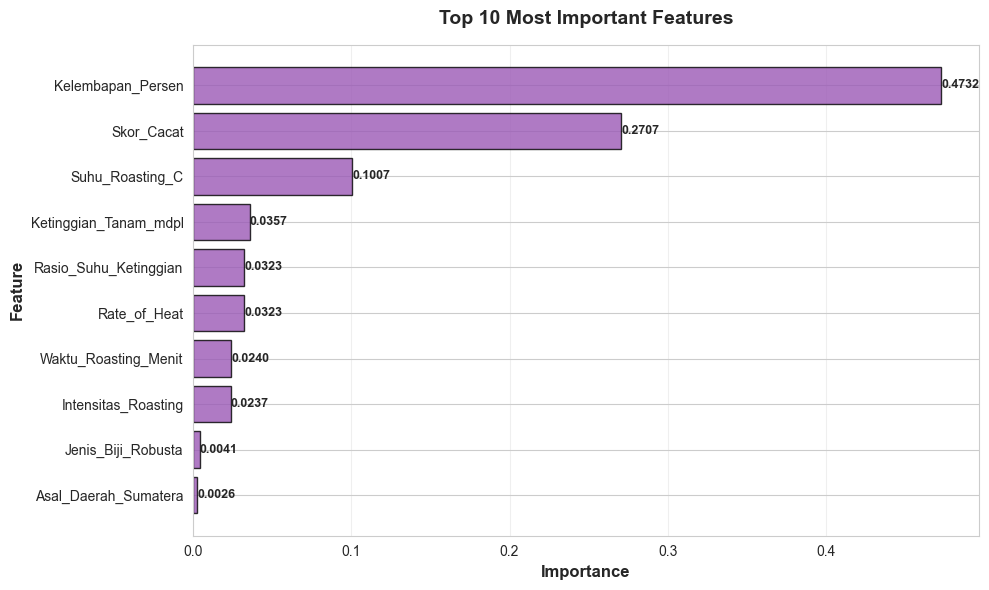

In [345]:
# Visualize top 10 features
top_features = importance_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_features['Feature'], top_features['Importance'], 
               color='#9b59b6', alpha=0.8, edgecolor='black')
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}',
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()